Agentic RAG

In [2]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

C:\Users\gupta\AppData\Local\Temp\ipykernel_6920\1139166428.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
urls=[
    "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
]
docs = [WebBaseLoader(urls).load() for url in urls]
docs


[[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n'),
  Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n'),
  Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n'),
  Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'langua

In [5]:
doc_list = [item for sublist in docs for item in sublist]
text_splitter =RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_splits =text_splitter.split_documents(doc_list)
   

vectorstore = FAISS.from_documents(
    documents = doc_splits,
    embedding = OllamaEmbeddings(model="nomic-embed-text")
   )
retriever = vectorstore.as_retriever()

C:\Users\gupta\AppData\Local\Temp\ipykernel_6920\868575984.py:8: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaEmbeddings``.
  embedding = OllamaEmbeddings(model="nomic-embed-text")


In [6]:
retriever.invoke("What is LangGraph?")

[Document(id='61c9ad21-ce39-40d8-a179-39746410d543', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='67ad7d23-30bf-4a9d-b394-30a7f7fedd8f', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='062c72d9-7879-4cac-919f-d4b262a13380', metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='81819b84-1f50-487a-b1b3-b86f488a7031', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]

In [7]:
### Retriever to Retriever Tools
from langchain_core.tools.retriever import create_retriever_tool
retriever_tools = create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and run information about LangGraph"
)

In [8]:
retriever_tools

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about LangGraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x0000028C3733FA60>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x0000028CA038A160>)

In [9]:
### Langchain Blogs - Seperate VectorDB
langchain_urls=[
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/"
]

docs=[WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEv

In [10]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add alll these text to vectordb

vectorstorelangchain=FAISS.from_documents(
    documents=doc_splits,
    embedding=OllamaEmbeddings(model="nomic-embed-text")
)


retrieverlangchain=vectorstorelangchain.as_retriever()

In [11]:
from langchain_core.tools.retriever import create_retriever_tool

retriever_tool_langchain=create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [12]:
tools=[retriever_tools,retriever_tool_langchain]

Langgraph workflow


In [15]:
from typing import Annotated,Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
class AgentState(TypedDict):
    #the add_messages function defines how an update should be proccesed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]
    
    

In [17]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3.6-27b")
llm.invoke("Hi")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user said "Hi". This is a simple greeting.\n2.  **Identify Intent:** The user is initiating a conversation. No specific question or request is made.\n3.  **Determine Response Strategy:** \n   - Acknowledge the greeting warmly\n   - Keep it open-ended to encourage further interaction\n   - Offer assistance\n   - Maintain a friendly, professional tone\n4.  **Draft Response (Mental):** "Hello! How can I assist you today?" or "Hi there! What\'s on your mind?" or "Hello! How can I help you today?"\n5.  **Refine Response:** "Hello! How can I assist you today?" is clear, polite, and open-ended. It matches standard AI assistant behavior.\n6.  **Final Output Generation:** Output the refined response.✅\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 203, 'prompt_tokens': 11, 'total_tokens': 214, 'completion_time': 0.3966287

In [19]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="qwen/qwen3.6-27b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [21]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain_classic import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

In [22]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="qwen/qwen3.6-27b")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [36]:
from langsmith import Client

client = Client()
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)

    # LLM
    llm = ChatGroq(model="qwen/qwen3.6-27b")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [37]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="qwen/qwen3.6-27b")
    response = model.invoke(msg)
    return {"messages": [response]}

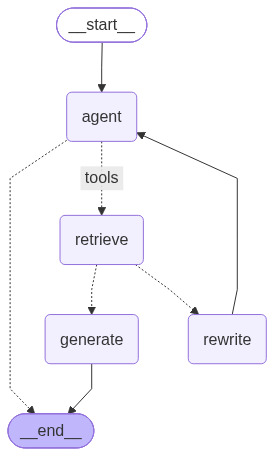

In [38]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tools,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [39]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='c55b4330-5402-4a0a-a4b2-c6e1213e0642'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Thinking Process:\n\n1.  **Understand the User\'s Request:** The user is asking "What is Langgraph?".\n2.  **Identify the Tool:** I have access to a tool named `retriever_vector_db_blog` which is specifically for searching information about LangGraph.\n3.  **Formulate the Query:** The query should be simple and direct, like "What is LangGraph" or "Introduction to LangGraph".\n4.  **Execute the Tool:** Call `retriever_vector_db_blog` with the query.\n5.  **Process the Output:** Summarize the retrieved information to answer the user\'s question clearly.\n\n*Self-Correction during thought process:* I shouldn\'t just guess based on general knowledge (though I know it\'s a library for building stateful, multi-actor applications with LLMs, specifically part of the LangChain ecosystem).

In [40]:
graph.invoke({"messages":"What is Langchain?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='b7c55d90-3150-4555-aca9-74a8ea6f1671'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Here\'s a thinking process:\n\n1.  **Analyze User Input:** The user asks "What is Langchain?"\n2.  **Identify Core Subject:** LangChain (often stylized as Langchain)\n3.  **Determine Information Needed:** Definition, purpose, key features, main components, use cases, and current status/context.\n4.  **Check Available Tools:** I have two retriever tools: `retriever_vector_db_blog` and `retriever_vector_langchain_blog`. The second one seems specifically tailored for LangChain information. I should use it to get accurate, up-to-date information from their blog/docs.\n5.  **Formulate Query:** "What is Langchain?" or "Langchain overview definition"\n6.  **Execute Tool Call:** `retriever_vector_langchain_blog` with query "What is Langchain?"\n7.  **Process Tool Response:** (I\'ll simul

In [41]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='b11a10a6-59ec-49ae-8766-8b222997bd97'),
  AIMessage(content='Machine learning (ML) is a subset of artificial intelligence (AI) that focuses on the development of computer programs that can access data and use it to learn for themselves.\n\nIn traditional programming, a human creates a set of rules for a computer to follow (e.g., "If X happens, do Y"). In machine learning, the computer analyzes data to find patterns and create its own rules to make predictions or decisions without being explicitly programmed to do so.\n\n**How it works:**\n1.  **Data:** You feed a large amount of data into a machine learning algorithm.\n2.  **Training:** The algorithm analyzes the data to find patterns and relationships.\n3.  **Model:** The result is a "model" (a mathematical representation of the pattern) that can be used to make predictions on new, unseen data.\n\n**The three main types of m